In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv(
    r"C:\Users\Haarini G\Desktop\zomato\zomato.csv",
    encoding="latin1",
    sep=",",
    engine="python",
    on_bad_lines="skip"
)

data.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30311 entries, 0 to 30310
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          30311 non-null  str  
 1   address                      30311 non-null  str  
 2   name                         30311 non-null  str  
 3   online_order                 30311 non-null  str  
 4   book_table                   30311 non-null  str  
 5   rate                         25802 non-null  str  
 6   votes                        30311 non-null  int64
 7   phone                        29687 non-null  str  
 8   location                     30302 non-null  str  
 9   rest_type                    30173 non-null  str  
 10  dish_liked                   13568 non-null  str  
 11  cuisines                     30287 non-null  str  
 12  approx_cost(for two people)  30174 non-null  str  
 13  reviews_list                 30311 non-null  str  
 14  m

In [4]:
data.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [5]:
data.shape

(30311, 17)

In [6]:
data.isna().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            4509
votes                              0
phone                            624
location                           9
rest_type                        138
dish_liked                     16743
cuisines                          24
approx_cost(for two people)      137
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [7]:
data.drop(['url', 'address', 'menu_item', 'phone','dish_liked'], axis = 1, inplace = True)

In [8]:
data.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'cuisines', 'approx_cost(for two people)', 'reviews_list',
       'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [9]:
data.shape

(30311, 12)

In [10]:
data.head(2)

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),reviews_list,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",Buffet,Banashankari


In [11]:
data.rename(columns={'name':'restaurant',
                     'rate':'rating',
                     'cuisines':'food_type',
                     "listed_in(type)":"type",
                     "listed_in(city)":"city",
                     "approx_cost(for two people)":"cost"},inplace=True)  

In [12]:
data.head()

,restaurant,online_order,book_table,rating,votes,location,rest_type,food_type,cost,reviews_list,type,city
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Buffet,Banashankari


In [13]:
data.isna().sum().sum()

np.int64(4817)

In [14]:
data.dropna(inplace = True)

In [15]:
data.shape

(25601, 12)

In [16]:
data.groupby('restaurant').count()

,online_order,book_table,rating,votes,location,rest_type,food_type,cost,reviews_list,type,city
restaurant,,,,,,,,,,,
#FeelTheROLL,1,1,1,1,1,1,1,1,1,1,1
#L-81 Cafe,6,6,6,6,6,6,6,6,6,6,6
#refuel,3,3,3,3,3,3,3,3,3,3,3
1000 B.C,4,4,4,4,4,4,4,4,4,4,4
100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C,3,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...
i-Bar - The Park Bangalore,6,6,6,6,6,6,6,6,6,6,6
iFruit Live Ice Creams,1,1,1,1,1,1,1,1,1,1,1
iSpice Resto Cafe,3,3,3,3,3,3,3,3,3,3,3


In [17]:
data['restaurant'].str.replace('[Ãx][^A-Za-z]+','',regex=True)

0                        Jalsa
1               Spice Elephant
2              San Churro Cafe
3        Addhuri Udupi Bhojana
4                Grand Village
                 ...          
30305        Punjabi Unplugged
30306     The Biriyani Factory
30307            Berry'd Alive
30309             Guns N Roses
30310          Sagar Fast Food
Name: restaurant, Length: 25601, dtype: str

In [18]:
data.groupby('restaurant').count()

,online_order,book_table,rating,votes,location,rest_type,food_type,cost,reviews_list,type,city
restaurant,,,,,,,,,,,
#FeelTheROLL,1,1,1,1,1,1,1,1,1,1,1
#L-81 Cafe,6,6,6,6,6,6,6,6,6,6,6
#refuel,3,3,3,3,3,3,3,3,3,3,3
1000 B.C,4,4,4,4,4,4,4,4,4,4,4
100ÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ°C,3,3,3,3,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...
i-Bar - The Park Bangalore,6,6,6,6,6,6,6,6,6,6,6
iFruit Live Ice Creams,1,1,1,1,1,1,1,1,1,1,1
iSpice Resto Cafe,3,3,3,3,3,3,3,3,3,3,3


In [19]:
data.online_order.unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [20]:
data.book_table.unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [21]:
data.rating.unique()

<StringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '3.6/5',  '4.6/5',  '4.0/5',  '4.2/5',
  '3.9/5',  '3.1/5',  '3.0/5',  '3.2/5',  '3.3/5',  '2.8/5',  '4.4/5',
  '4.3/5',    'NEW',  '2.9/5',  '3.5/5',  '2.6/5', '3.8 /5',  '3.4/5',
  '4.5/5',  '2.5/5',  '2.7/5',  '4.7/5',  '2.4/5',  '2.2/5',  '2.3/5',
 '3.4 /5',      '-', '3.6 /5',  '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
 '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5', '3.5 /5',
 '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5', '4.3 /5', '4.4 /5',
  '4.9/5',  '2.1/5',  '2.0/5',  '1.8/5', '4.6 /5', '4.9 /5', '3.0 /5',
 '4.8 /5', '2.3 /5', '2.4 /5', '4.7 /5']
Length: 60, dtype: str

In [22]:
replace = lambda x:x.replace('/5', "")
l = []
for val in map(replace,data['rating']):
    if val != 'NEW' and val != "-":
        var = float(val)
    l.append(var)
data['rating'] = l

In [23]:
data.rating.unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2, 2.3,
       4.8, 4.9, 2.1, 2. , 1.8])

In [24]:
data['votes'].isnull().value_counts()

votes
False    25601
Name: count, dtype: int64

In [25]:
data.location.unique()

<StringArray>
[                 'Banashankari',                  'Basavanagudi',
                   'Mysore Road',                     'Jayanagar',
            'Kumaraswamy Layout',          'Rajarajeshwari Nagar',
                   'Vijay Nagar',                   'Uttarahalli',
                      'JP Nagar',               'South Bangalore',
                   'City Market',             'Bannerghatta Road',
                           'BTM',               'Kanakapura Road',
                  'Bommanahalli',                'CV Raman Nagar',
               'Electronic City',                 'Wilson Garden',
                  'Shanti Nagar',         'Koramangala 5th Block',
                 'Richmond Road',                           'HSR',
                  'Marathahalli',         'Koramangala 7th Block',
                     'Bellandur',                 'Sarjapur Road',
                    'Whitefield',                'East Bangalore',
              'Old Airport Road',               

In [26]:
data['rest_type'].unique()

<StringArray>
[                'Casual Dining',           'Cafe, Casual Dining',
                   'Quick Bites',           'Casual Dining, Cafe',
                          'Cafe',             'Quick Bites, Cafe',
             'Cafe, Quick Bites',                      'Delivery',
                          'Mess',                'Dessert Parlor',
        'Bakery, Dessert Parlor',                           'Pub',
                        'Bakery',            'Takeaway, Delivery',
                   'Fine Dining',                 'Beverage Shop',
                    'Sweet Shop',                           'Bar',
    'Dessert Parlor, Sweet Shop',           'Bakery, Quick Bites',
       'Sweet Shop, Quick Bites',                         'Kiosk',
                    'Food Truck',   'Quick Bites, Dessert Parlor',
    'Beverage Shop, Quick Bites', 'Beverage Shop, Dessert Parlor',
                      'Takeaway',            'Pub, Casual Dining',
            'Casual Dining, Bar', 'Dessert Parlo

In [27]:
data.food_type.unique()

<StringArray>
[                   'North Indian, Mughlai, Chinese',
                       'Chinese, North Indian, Thai',
                            'Cafe, Mexican, Italian',
                        'South Indian, North Indian',
                          'North Indian, Rajasthani',
                                      'North Indian',
       'North Indian, South Indian, Andhra, Chinese',
                              'Pizza, Cafe, Italian',
                        'Cafe, Italian, Continental',
          'Cafe, Mexican, Italian, Momos, Beverages',
 ...
                      'North Indian, Kebab, Mughlai',
                            'Sandwich, Pizza, Salad',
                                'Seafood, Fast Food',
                    'European, Mediterranean, Salad',
 'South Indian, North Indian, Continental, European',
                    'South Indian, Seafood, Biryani',
  'North Indian, Fast Food, Kebab, Rolls, Beverages',
           'North Indian, Chinese, Rolls, Fast Food',
         

In [28]:
data.cost.unique()

<StringArray>
[  '800',   '300',   '600',   '700',   '550',   '500',   '450',   '650',
   '400',   '900',   '200',   '750',   '150',   '850',   '100', '1,200',
   '350',   '250',   '950', '1,000', '1,500', '1,300',   '199',    '80',
 '1,100',   '160', '1,600',   '230',   '130', '1,700', '1,400', '1,350',
 '2,200', '2,000', '1,800', '1,900',   '180',   '330', '2,500', '2,100',
 '3,000', '2,800', '3,400',    '50',    '40', '1,250', '3,500', '4,000',
 '2,400', '2,600', '1,450',    '70', '3,200',   '560',   '240',   '360',
 '6,000', '1,050', '2,300']
Length: 59, dtype: str

In [29]:
data['cost'] = data['cost'].apply(lambda x:x.replace(",","")).astype(int)            

In [30]:
data.cost.unique()

array([ 800,  300,  600,  700,  550,  500,  450,  650,  400,  900,  200,
        750,  150,  850,  100, 1200,  350,  250,  950, 1000, 1500, 1300,
        199,   80, 1100,  160, 1600,  230,  130, 1700, 1400, 1350, 2200,
       2000, 1800, 1900,  180,  330, 2500, 2100, 3000, 2800, 3400,   50,
         40, 1250, 3500, 4000, 2400, 2600, 1450,   70, 3200,  560,  240,
        360, 6000, 1050, 2300])

In [31]:
data.cost.dtype

dtype('int64')

In [32]:
data.columns

Index(['restaurant', 'online_order', 'book_table', 'rating', 'votes',
       'location', 'rest_type', 'food_type', 'cost', 'reviews_list', 'type',
       'city'],
      dtype='str')

In [33]:
data.type.unique()

<StringArray>
[            'Buffet',              'Cafes',           'Delivery',
           'Desserts',           'Dine-out', 'Drinks & nightlife',
      'Pubs and bars']
Length: 7, dtype: str

In [34]:
data.city.unique()

<StringArray>
[         'Banashankari',     'Bannerghatta Road',          'Basavanagudi',
             'Bellandur',          'Brigade Road',           'Brookefield',
                   'BTM',         'Church Street',       'Electronic City',
           'Frazer Town',                   'HSR',           'Indiranagar',
             'Jayanagar',              'JP Nagar',          'Kalyan Nagar',
          'Kammanahalli', 'Koramangala 4th Block', 'Koramangala 5th Block']
Length: 18, dtype: str

In [35]:
data.duplicated().value_counts()

False    25565
True        36
Name: count, dtype: int64

In [36]:
data.drop_duplicates(keep='last', inplace=True)
data.reset_index(drop=True, inplace=True)

In [37]:
data.duplicated().value_counts()

False    25565
Name: count, dtype: int64

In [38]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25565 entries, 0 to 25564
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   restaurant    25565 non-null  str    
 1   online_order  25565 non-null  str    
 2   book_table    25565 non-null  str    
 3   rating        25565 non-null  float64
 4   votes         25565 non-null  int64  
 5   location      25565 non-null  str    
 6   rest_type     25565 non-null  str    
 7   food_type     25565 non-null  str    
 8   cost          25565 non-null  int64  
 9   reviews_list  25565 non-null  str    
 10  type          25565 non-null  str    
 11  city          25565 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


#DATA VISUALIZATION

In [39]:
data.to_csv(r"C:\Users\Haarini G\Desktop\zomato\zomato_clean.csv")

In [40]:
!pip install seaborn matplotlib pandas
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [41]:
#loading clean data
data = pd.read_csv(
    r"C:\Users\Haarini G\Desktop\zomato\zomato_clean.csv", index_col = 0
)

data.head()

,restaurant,online_order,book_table,rating,votes,location,rest_type,food_type,cost,reviews_list,type,city
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Buffet,Banashankari


In [42]:
data.shape

(25565, 12)

1. How many restaurants are accepting online order for zomato?

In [43]:
data.online_order.value_counts()

online_order
Yes    17396
No      8169
Name: count, dtype: int64

<Axes: xlabel='online_order'>

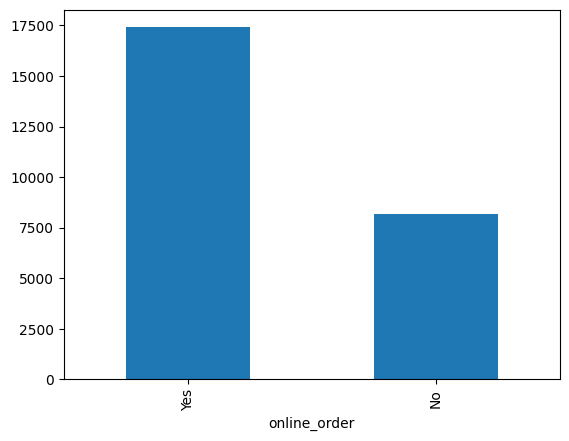

In [44]:
data.online_order.value_counts().plot(kind='bar')

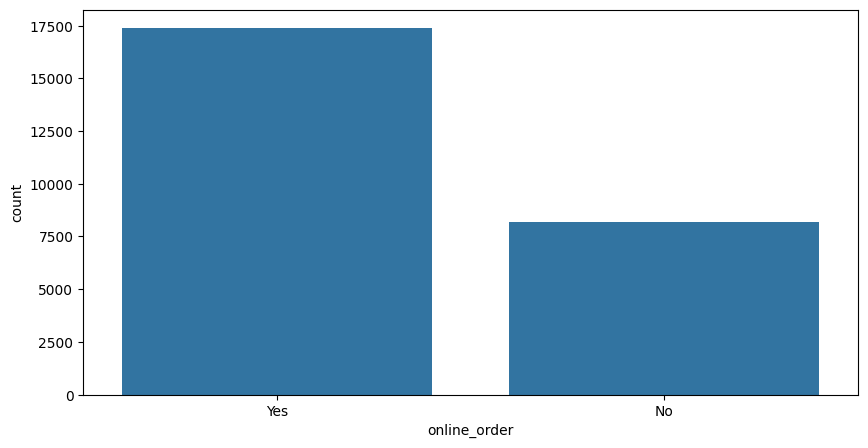

In [45]:
plt.figure(figsize=(10,5))
sns.countplot(x='online_order',data=data)
plt.show()

Given the dataset, there are 17396 restaurants which delivers online and remaining 8169 does not deliver online

2. Find best location by seeing dataset.

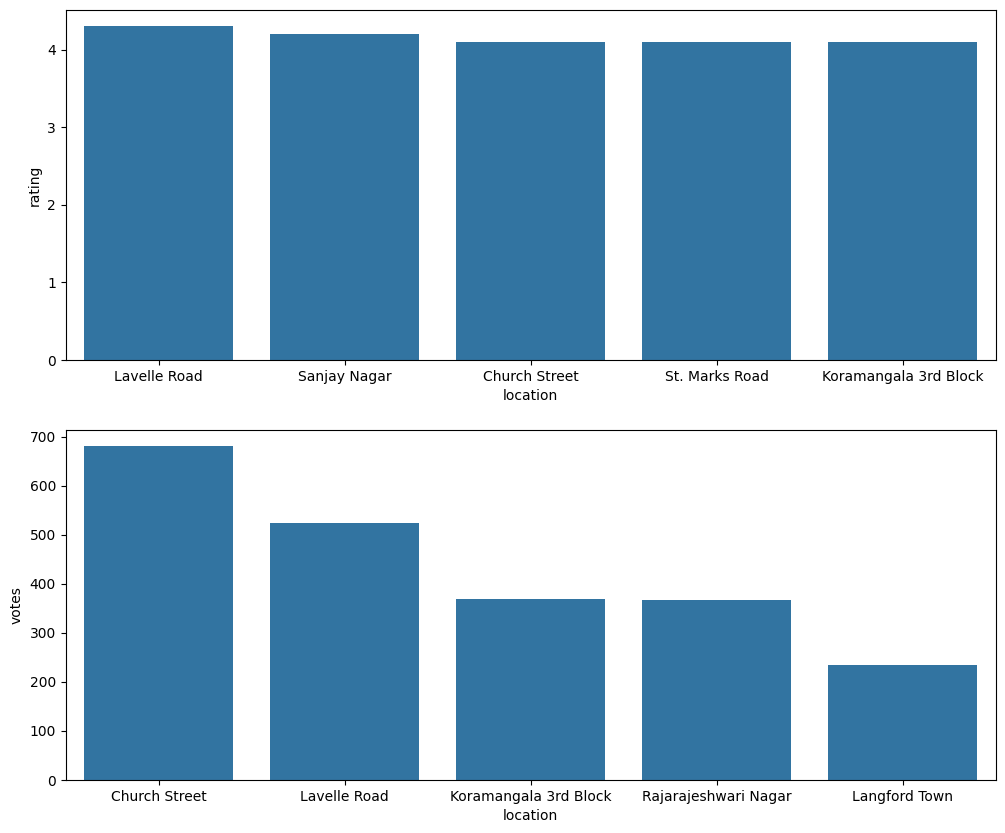

In [46]:
plt.figure(figsize=(12,10))
ax = plt.subplot(2,1,1)

#sorting location on avg of rating in descending order and reading first 5 values
loc_rating = data.groupby('location').agg({'rating':'median'})
rating_sorted_loc = loc_rating.sort_values('rating',ascending=False).head(5).reset_index()

#plotting graph using seaborn
sns.barplot(x='location',y='rating',data=rating_sorted_loc)


ax = plt.subplot(2,1,2)

#sorting location on avg of votes in descending order and reading forst 5 values
loc_votes=data.groupby('location').agg({'votes':'median'})
votes_sorted_loc=loc_votes.sort_values('votes', ascending=False).head(5).reset_index()

#plotting graph using sns
sns.barplot(x='location',y='votes',data=votes_sorted_loc)
plt.show()

3. Find types of restaurants and their count

(np.int64(84), <Axes: xlabel='restaurant', ylabel='rest_type'>)

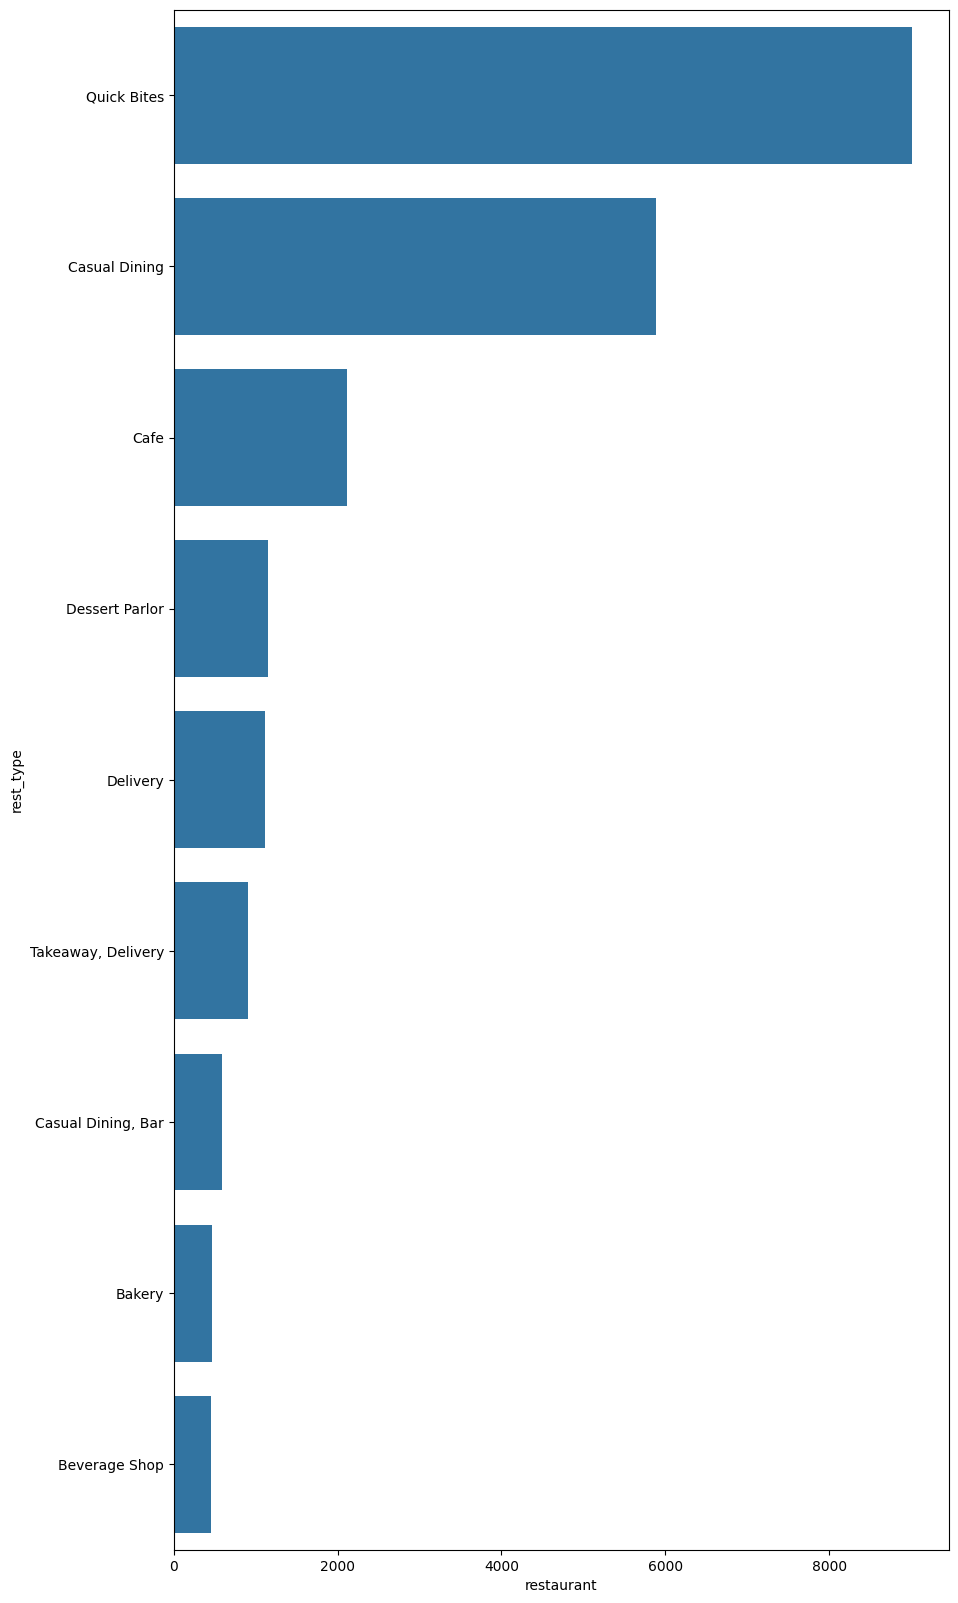

In [47]:
plt.figure(figsize=(10,20))
rest_types = data.groupby('rest_type')['restaurant'].count().reset_index() #group restaurants by type and count how many restaurants belong to each type.
sorted_rest_types = rest_types.sort_values('restaurant',ascending=False).head(9)
#print(sorted_rest_types)

rest_types.rest_type.count(),sns.barplot(x='restaurant',y='rest_type',data=sorted_rest_types,orient='h')

4. Find cost of restaurants

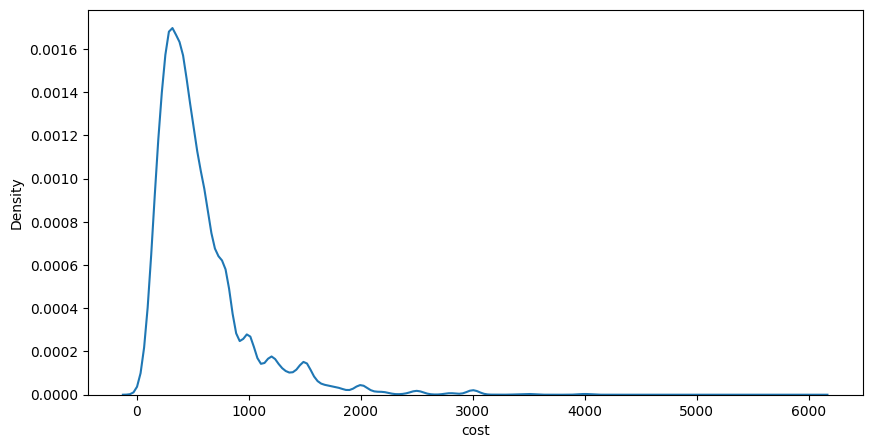

In [48]:
plt.figure(figsize=(10,5))
sns.kdeplot(x='cost',data=data)
plt.show()

5. Find the count of restaurants have table booking facility

In [52]:
data['book_table'].value_counts()

book_table
No     22118
Yes     3447
Name: count, dtype: int64

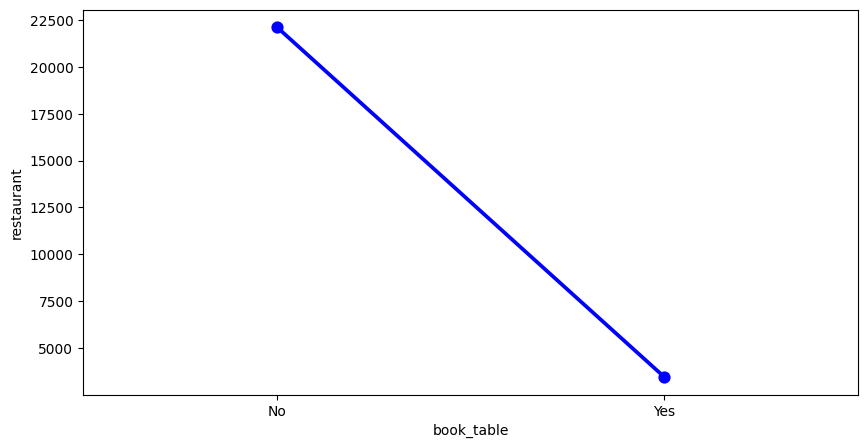

In [54]:
plt.figure(figsize=(10,5))
table_booking = data.groupby('book_table')['restaurant'].count().reset_index()
sns.pointplot(x='book_table',y='restaurant',color='b',data=table_booking)
plt.show()

6. Find number of restaurants at given locations.
1)BTM
2)Basavanagudi
3)Kalyan Nagar
4)Whitefield
5)Uttarahalli

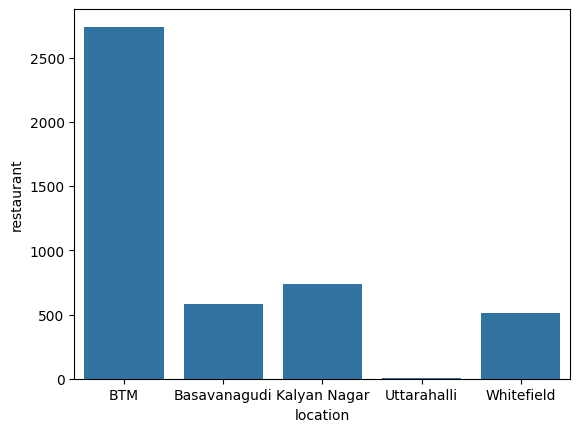

In [59]:
df = pd.DataFrame(data.groupby('location')['restaurant'].count()).reset_index()

criteria=df['location'].isin(['BTM','Basavanagudi','Kalyan Nagar','Whitefield','Uttarahalli'])
sns.barplot(x='location',y='restaurant',data=df[criteria])
plt.show()


In [58]:
print(df['location'].unique())

<StringArray>
[                          'BTM',                  'Banashankari',
                     'Banaswadi',             'Bannerghatta Road',
                  'Basavanagudi',                     'Bellandur',
                  'Bommanahalli',                  'Brigade Road',
                   'Brookefield',                'CV Raman Nagar',
             'Central Bangalore',                 'Church Street',
                   'City Market',             'Commercial Street',
               'Cunningham Road',                        'Domlur',
                'East Bangalore',                       'Ejipura',
               'Electronic City',                   'Frazer Town',
                    'HBR Layout',                           'HSR',
                        'Hebbal',                        'Hennur',
                    'Hosur Road',    'ITPL Main Road, Whitefield',
                   'Indiranagar',                 'Infantry Road',
                      'JP Nagar',               